<H3>Foot Traffic Prediction:</H2> 
<h4>Predict the daily number of visitors to a retail store using historical footfall data, weather patterns, and promotional events.</h4>

In [1]:
# Dummy Data Set created for Foot Traffic Prediction of 500 rows

import pandas as pd
import numpy as np

np.random.seed(42)  # For reproducibility

# Generate dates
dates = pd.date_range(start="2024-01-01", periods=500, freq='D')
day_of_week = dates.day_name()

# Weather conditions
weather_conditions = ['Sunny', 'Cloudy', 'Rainy']
weather = np.random.choice(weather_conditions, size=500, p=[0.5, 0.3, 0.2])

# Temperature (°C)
temp_base = np.random.normal(25, 4, 500)  # Average temp with some variance
temp = np.clip(temp_base + np.where(weather == 'Rainy', -4, 0), 15, 35)

# Rain (mm)
rain = np.where(weather == 'Rainy', np.random.randint(1, 10, 500), np.random.choice([0, 0, 0, 1], 500))

# Promo event
promo_event = np.where(np.random.rand(500) < 0.15, 'Yes', 'No')  # 15% chance of promo

# Holiday: Assume some fixed holidays e.g., Sundays, or random ones
holiday = np.where(day_of_week == 'Sunday', 'Yes', np.where(np.random.rand(500) < 0.05, 'Yes', 'No'))

# Footfall - base it with some logic, e.g., higher on weekends, promos, good weather
footfall = (180 
            + (day_of_week.isin(['Saturday', 'Sunday'])) * np.random.randint(30, 70, 500)
            + (weather == 'Sunny') * np.random.randint(10, 30, 500)
            - (weather == 'Rainy') * np.random.randint(20, 50, 500)
            + (promo_event == 'Yes') * np.random.randint(40, 90, 500)
            + (holiday == 'Yes') * np.random.randint(0, 20, 500)
            + np.random.randint(-20, 20, 500))

# Ensure no negative footfall
footfall = np.maximum(footfall, 20)

# Create the DataFrame
data = pd.DataFrame({
    'Date': dates,
    'DayOfWeek': day_of_week,
    'Weather': weather,
    'Temp_C': temp.round(1),
    'Rain_mm': rain,
    'Promo_Event': promo_event,
    'Holiday': holiday,
    'Footfall': footfall.astype(int)
})

# Save to CSV
data.to_csv('foot_traffic_dummy.csv', index=False)

print("Dummy dataset 'foot_traffic_dummy.csv' created with 500 rows.")

Dummy dataset 'foot_traffic_dummy.csv' created with 500 rows.


In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         500 non-null    datetime64[us]
 1   DayOfWeek    500 non-null    str           
 2   Weather      500 non-null    str           
 3   Temp_C       500 non-null    float64       
 4   Rain_mm      500 non-null    int64         
 5   Promo_Event  500 non-null    str           
 6   Holiday      500 non-null    str           
 7   Footfall     500 non-null    int64         
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 31.4 KB


In [3]:
data.isnull().sum()

Date           0
DayOfWeek      0
Weather        0
Temp_C         0
Rain_mm        0
Promo_Event    0
Holiday        0
Footfall       0
dtype: int64

In [4]:
# Binary mapping for 'Promo_Event' and 'Holiday'
data['Promo_Event'] = data['Promo_Event'].map({'No': 0, 'Yes': 1})
data['Holiday'] = data['Holiday'].map({'No': 0, 'Yes': 1})

# One-hot encoding for 'DayOfWeek' and 'Weather'
data = pd.get_dummies(data, columns=['DayOfWeek', 'Weather'])


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 500 non-null    datetime64[us]
 1   Temp_C               500 non-null    float64       
 2   Rain_mm              500 non-null    int64         
 3   Promo_Event          500 non-null    int64         
 4   Holiday              500 non-null    int64         
 5   Footfall             500 non-null    int64         
 6   DayOfWeek_Friday     500 non-null    bool          
 7   DayOfWeek_Monday     500 non-null    bool          
 8   DayOfWeek_Saturday   500 non-null    bool          
 9   DayOfWeek_Sunday     500 non-null    bool          
 10  DayOfWeek_Thursday   500 non-null    bool          
 11  DayOfWeek_Tuesday    500 non-null    bool          
 12  DayOfWeek_Wednesday  500 non-null    bool          
 13  Weather_Cloudy       500 non-null    bool     

In [5]:
data['Is_Weekend'] = data[['DayOfWeek_Saturday', 'DayOfWeek_Sunday']].max(axis=1)

In [6]:
# Footfall value from previous day
data['Footfall_Lag1'] = data['Footfall'].shift(1)
# From 7 days ago
data['Footfall_Lag7'] = data['Footfall'].shift(7)

In [7]:
# Average footfall over the last 3 days (including today)
data['Footfall_Rolling3'] = data['Footfall'].rolling(window=3).mean()
# Or last 7 days
data['Footfall_Rolling7'] = data['Footfall'].rolling(window=7).mean()

In [8]:
data.head(10)

,Date,Temp_C,Rain_mm,Promo_Event,Holiday,Footfall,DayOfWeek_Friday,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,...,DayOfWeek_Tuesday,DayOfWeek_Wednesday,Weather_Cloudy,Weather_Rainy,Weather_Sunny,Is_Weekend,Footfall_Lag1,Footfall_Lag7,Footfall_Rolling3,Footfall_Rolling7
0,2024-01-01,26.4,0,0,0,199,False,True,False,False,...,False,False,False,False,True,False,NaN,NaN,NaN,NaN
1,2024-01-02,28.5,6,0,0,126,False,False,False,False,...,True,False,False,True,False,False,199.0,NaN,NaN,NaN
2,2024-01-03,28.8,1,0,0,188,False,False,False,False,...,False,True,True,False,False,False,126.0,NaN,171.000000,NaN
3,2024-01-04,22.7,0,0,0,193,False,False,False,False,...,False,False,True,False,False,False,188.0,NaN,169.000000,NaN
4,2024-01-05,21.4,0,0,0,195,True,False,False,False,...,False,False,False,False,True,False,193.0,NaN,192.000000,NaN
5,2024-01-06,27.0,0,0,0,246,False,False,True,False,...,False,False,False,False,True,True,195.0,NaN,211.333333,NaN
6,2024-01-07,19.7,0,0,1,265,False,False,False,True,...,False,False,False,False,True,True,246.0,NaN,235.333333,201.714286
7,2024-01-08,28.3,9,0,0,165,False,True,False,False,...,False,False,False,True,False,False,265.0,199.0,225.333333,196.857143
8,2024-01-09,29.7,1,0,0,184,False,False,False,False,...,True,False,True,False,False,False,165.0,126.0,204.666667,205.142857
9,2024-01-10,23.1,0,0,0,197,False,False,False,False,...,False,True,True,False,False,False,184.0,188.0,182.000000,206.428571


In [10]:
# Removed the rows with null values, which were created 
# Footfall_Lag1          0
# Footfall_Lag7          5
# Footfall_Rolling3      1
# Footfall_Rolling7      4

print(data.isnull().sum())


Date                   0
Temp_C                 0
Rain_mm                0
Promo_Event            0
Holiday                0
Footfall               0
DayOfWeek_Friday       0
DayOfWeek_Monday       0
DayOfWeek_Saturday     0
DayOfWeek_Sunday       0
DayOfWeek_Thursday     0
DayOfWeek_Tuesday      0
DayOfWeek_Wednesday    0
Weather_Cloudy         0
Weather_Rainy          0
Weather_Sunny          0
Is_Weekend             0
Footfall_Lag1          1
Footfall_Lag7          7
Footfall_Rolling3      2
Footfall_Rolling7      6
dtype: int64


In [11]:
data = data.dropna()

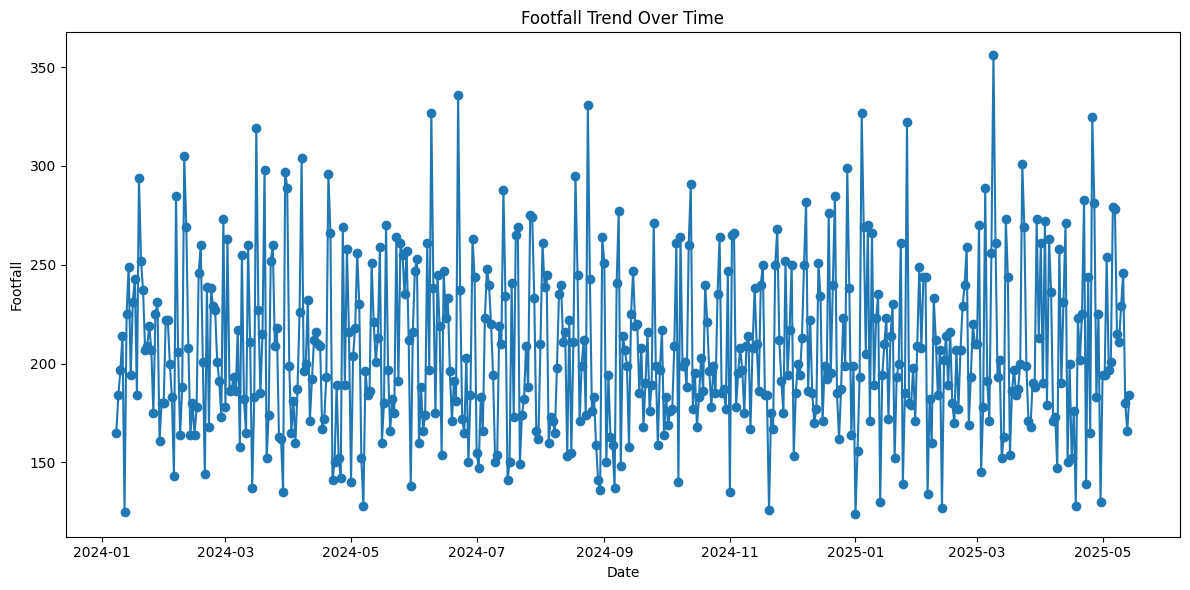

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Footfall'], marker='o', linestyle='-')
plt.xlabel('Date')
plt.ylabel('Footfall')
plt.title('Footfall Trend Over Time')
plt.tight_layout()
plt.show()

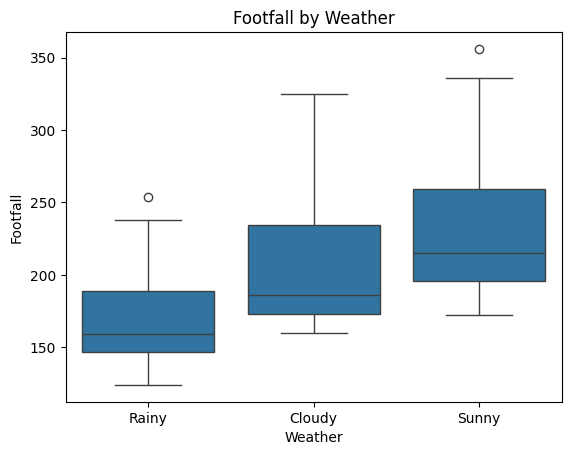

In [13]:
weather_cols = [col for col in data.columns if col.startswith('Weather_')]
data['Weather'] = np.select(
    [data[col]==1 for col in weather_cols],
    [col.replace('Weather_', '') for col in weather_cols],
    default='Other'
)

# Now plot
sns.boxplot(x='Weather', y='Footfall', data=data)
plt.title('Footfall by Weather')
plt.show()

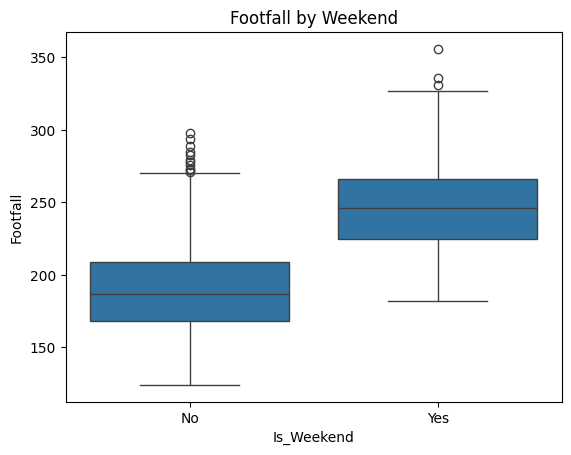

In [14]:
sns.boxplot(x='Is_Weekend', y='Footfall', data=data)
plt.xticks([0,1], ['No', 'Yes'])
plt.title('Footfall by Weekend')
plt.show()

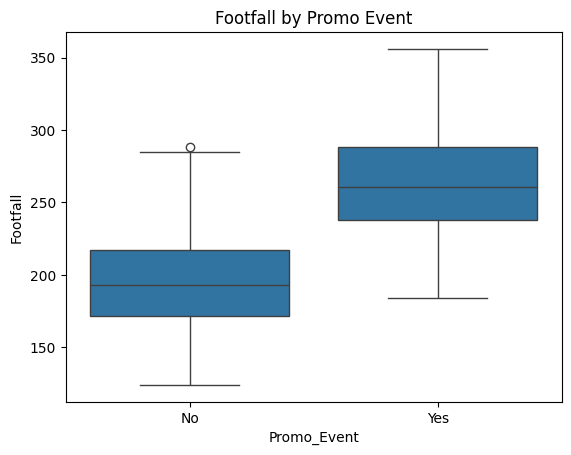

In [15]:
sns.boxplot(x='Promo_Event', y='Footfall', data=data)
plt.xticks([0,1], ['No', 'Yes'])
plt.title('Footfall by Promo Event')
plt.show()

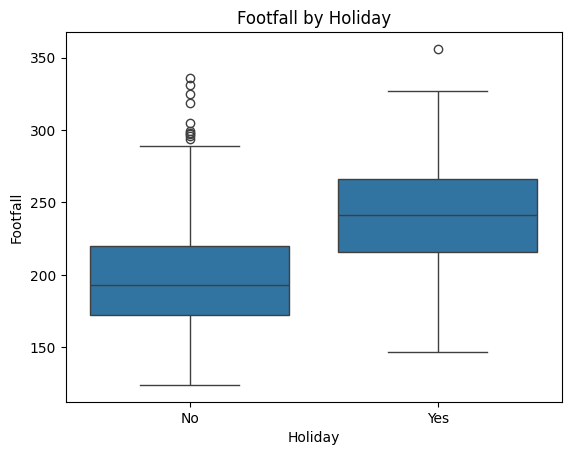

In [16]:
sns.boxplot(x='Holiday', y='Footfall', data=data)
plt.xticks([0,1], ['No', 'Yes'])
plt.title('Footfall by Holiday')
plt.show()

In [17]:
data.columns

Index(['Date', 'Temp_C', 'Rain_mm', 'Promo_Event', 'Holiday', 'Footfall',
       'DayOfWeek_Friday', 'DayOfWeek_Monday', 'DayOfWeek_Saturday',
       'DayOfWeek_Sunday', 'DayOfWeek_Thursday', 'DayOfWeek_Tuesday',
       'DayOfWeek_Wednesday', 'Weather_Cloudy', 'Weather_Rainy',
       'Weather_Sunny', 'Is_Weekend', 'Footfall_Lag1', 'Footfall_Lag7',
       'Footfall_Rolling3', 'Footfall_Rolling7', 'Weather'],
      dtype='str')

In [18]:
data = data.drop(['Weather'], axis=1)

In [19]:
data.columns

Index(['Date', 'Temp_C', 'Rain_mm', 'Promo_Event', 'Holiday', 'Footfall',
       'DayOfWeek_Friday', 'DayOfWeek_Monday', 'DayOfWeek_Saturday',
       'DayOfWeek_Sunday', 'DayOfWeek_Thursday', 'DayOfWeek_Tuesday',
       'DayOfWeek_Wednesday', 'Weather_Cloudy', 'Weather_Rainy',
       'Weather_Sunny', 'Is_Weekend', 'Footfall_Lag1', 'Footfall_Lag7',
       'Footfall_Rolling3', 'Footfall_Rolling7'],
      dtype='str')

In [20]:
from sklearn.model_selection import train_test_split

# Assume your features are in X and your target is in y
# For example:
X = data.drop(['Footfall', 'Date'], axis=1)  # Features (drop target and date)
y = data['Footfall']  # Target variable

# Split data: 80% train, 20% test (commonly used)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
print(X_train.dtypes)

Temp_C                 float64
Rain_mm                  int64
Promo_Event              int64
Holiday                  int64
DayOfWeek_Friday          bool
DayOfWeek_Monday          bool
DayOfWeek_Saturday        bool
DayOfWeek_Sunday          bool
DayOfWeek_Thursday        bool
DayOfWeek_Tuesday         bool
DayOfWeek_Wednesday       bool
Weather_Cloudy            bool
Weather_Rainy             bool
Weather_Sunny             bool
Is_Weekend                bool
Footfall_Lag1          float64
Footfall_Lag7          float64
Footfall_Rolling3      float64
Footfall_Rolling7      float64
dtype: object


In [22]:
# Convert all boolean columns to int (0/1)
X_train = X_train.astype(int)
X_test = X_test.astype(int)

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
# Predict on test set
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared:", r2)

Mean Absolute Error (MAE): 12.063960205983488
Root Mean Squared Error (RMSE): 15.304054168517993
R-squared: 0.878744108741546


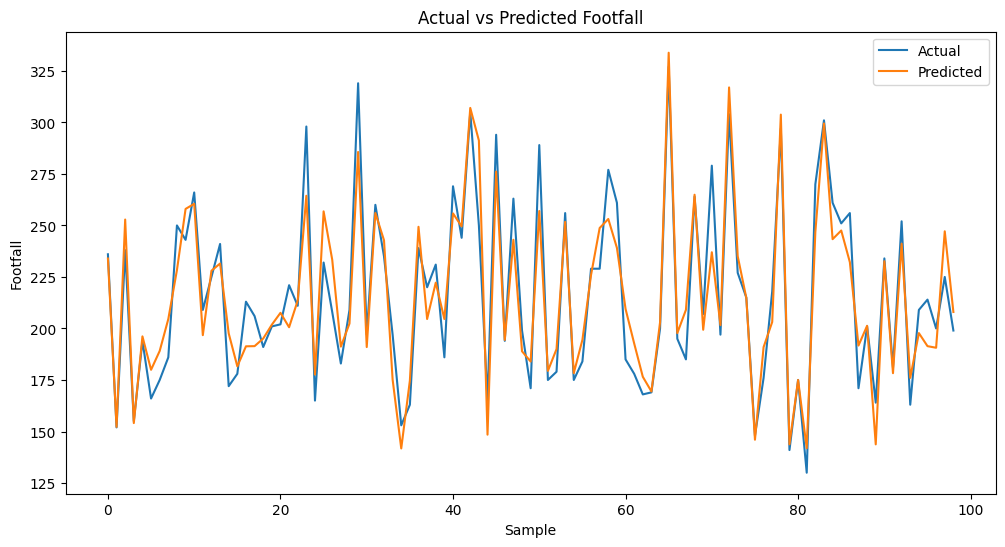

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title('Actual vs Predicted Footfall')
plt.xlabel('Sample')
plt.ylabel('Footfall')
plt.show()

My Model Evaluation Results 

    Mean Absolute Error (MAE): 12.06
    On average, my model’s predictions are within about 12 visitors of the actual footfall. Given that the daily footfall typically ranges from 100 to 300, this is a relatively small error. 

    Root Mean Squared Error (RMSE): 15.30
    This metric, which penalizes larger errors more than MAE, is also quite low compared to the range of daily footfall values. 

    R-squared (R²): 0.879
    My model explains nearly 88% of the variation in the actual data, which is considered very strong for this type of real-world prediction problem. 
     

<H3>Testing this Model</H3>

In [27]:
r2 = r2_score(y_test, y_pred)
print(f"R-squared (R²): {r2:.2f}")


R-squared (R²): 0.88
